In [ ]:
!pip install earthengine-api geemap pandas matplotlib seaborn

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ee.Authenticate()

# Inicializar
ee.Initialize(project='ee-deicyduarte1112')

In [ ]:
# Coordenadas de Puerto Wilches
# Un rectángulo que capture un meandro del río
roi = ee.Geometry.Rectangle([-73.95, 7.30, -73.85, 7.40])
# rango de tiempo
years = list(range(2016, 2025))
years

# Visualizar el área con geemap
Map = geemap.Map()
Map.centerObject(roi, 12)
Map.addLayer(roi, {}, 'ROI')
Map

Map(center=[7.350000891986699, -73.8999999999989], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:


collection = (ee.ImageCollection('COPERNICUS/S2')
              .filterBounds(roi)
              .filterDate('2016-01-01','2024-12-31'))

print(collection.size().getInfo())

570


In [ ]:
def get_s2_collection(year):

    start = ee.Date.fromYMD(year,1,1)
    end = start.advance(1,'year')

    collection = (ee.ImageCollection('COPERNICUS/S2')
                  .filterBounds(roi)
                  .filterDate(start,end)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',60))
                  .select(['B3','B8']))

    return collection

In [ ]:
for year in years:

    collection = get_s2_collection(year)

    n = collection.size().getInfo()

    print(year, n)

2016 8
2017 13
2018 39
2019 31
2020 40
2021 39
2022 34
2023 30
2024 33


In [ ]:
#revisar como funcionan las correcciones radiometricas y como afecta la temporalidad a las imagenes para garantizar integridad de los datos.

In [ ]:
def annual_composite(year):

    collection = get_s2_collection(year)

    composite = collection.median().clip(roi)

    return composite.set('year',year)



In [ ]:
annual_images = [annual_composite(year) for year in years]

In [ ]:
for img in annual_images:

    print(img.get('year').getInfo())

2016
2017
2018
2019
2020
2021
2022
2023
2024


In [ ]:
def calculate_ndwi(image):

    ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')

    return image.addBands(ndwi)

In [ ]:
ndwi_images = [calculate_ndwi(img) for img in annual_images]
for img in ndwi_images:

    year = img.get('year').getInfo()

    print("NDWI calculado para:", year)

NDWI calculado para: 2016
NDWI calculado para: 2017
NDWI calculado para: 2018
NDWI calculado para: 2019
NDWI calculado para: 2020
NDWI calculado para: 2021
NDWI calculado para: 2022
NDWI calculado para: 2023
NDWI calculado para: 2024


In [ ]:
img2021 = [img for img in ndwi_images if img.get('year').getInfo() == 2021][0]

Map = geemap.Map()
Map.centerObject(roi,12)

Map.addLayer(
    img2021.select('NDWI'),
    {"min":-1,"max":1,"palette":["brown","white","blue"]},
    "NDWI 2020"
)

Map

Map(center=[7.350000891986699, -73.8999999999989], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
def water_mask(image):

    ndwi = image.select('NDWI')

    water = ndwi.gt(0).rename('water')

    return image.addBands(water)

In [ ]:
water_images = [water_mask(img) for img in ndwi_images]

In [ ]:
def compute_metrics(image):

    water = image.select('water')
    ndwi = image.select('NDWI')

    # área de agua
    water_area = water.multiply(ee.Image.pixelArea()).rename('water_area')

    # combinar bandas
    combined = ee.Image.cat([
        water_area,
        ndwi
    ])

    stats = combined.reduceRegion(
        reducer = ee.Reducer.sum().combine(
            reducer2 = ee.Reducer.mean(),
            sharedInputs = True
        ).combine(
            reducer2 = ee.Reducer.stdDev(),
            sharedInputs = True
        ),
        geometry = roi,
        scale = 10,
        maxPixels = 1e9
    )

    return ee.Feature(None,{
        'year': image.get('year'),
        'water_area_m2': stats.get('water_area_sum'),
        'mean_ndwi': stats.get('NDWI_mean'),
        'std_ndwi': stats.get('NDWI_stdDev')
    })

In [ ]:
features = [compute_metrics(img) for img in water_images]

fc = ee.FeatureCollection(features)

data = fc.getInfo()

In [ ]:
rows = [f['properties'] for f in data['features']]

df = pd.DataFrame(rows)

df = df.sort_values('year')

df['water_area_km2'] = df['water_area_m2'] / 1e6

df['water_area_change_rate'] = df['water_area_km2'].pct_change() * 100

df = df[['year','water_area_km2','mean_ndwi','std_ndwi','water_area_change_rate']]

df

,year,water_area_km2,mean_ndwi,std_ndwi,water_area_change_rate
0,2016,10.384845,-0.426678,0.192639,NaN
1,2017,14.208328,-0.437642,0.231285,36.817906
2,2018,12.311069,-0.407505,0.187007,-13.353145
3,2019,11.797440,-0.406667,0.184577,-4.172096
4,2020,11.119178,-0.415462,0.185175,-5.749224
5,2021,13.180181,-0.427453,0.203367,18.535570
6,2022,15.326183,-0.273882,0.140364,16.282034
7,2023,14.035282,-0.282865,0.135669,-8.422848
8,2024,11.454973,-0.263547,0.124186,-18.384447


In [ ]:
df.describe()

,year,water_area_km2,mean_ndwi,std_ndwi,water_area_change_rate
count,9.000000,9.000000,9.000000,9.000000,8.000000
mean,2020.000000,12.646387,-0.371300,0.176030,2.694219
std,2.738613,1.640674,0.074208,0.035253,19.063272
min,2016.000000,10.384845,-0.437642,0.124186,-18.384447
25%,2018.000000,11.454973,-0.426678,0.140364,-9.655422
50%,2020.000000,12.311069,-0.407505,0.185175,-4.960660
75%,2022.000000,14.035282,-0.282865,0.192639,16.845418
max,2024.000000,15.326183,-0.263547,0.231285,36.817906


In [ ]:
df.corr(numeric_only=True)

,year,water_area_km2,mean_ndwi,std_ndwi,water_area_change_rate
year,1.000000,0.310870,0.838541,-0.822358,-0.422370
water_area_km2,0.310870,1.000000,0.366282,-0.111156,0.658548
mean_ndwi,0.838541,0.366282,1.000000,-0.948666,-0.382493
std_ndwi,-0.822358,-0.111156,-0.948666,1.000000,0.618868
water_area_change_rate,-0.422370,0.658548,-0.382493,0.618868,1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta viva personalizada
palette_viva = ["#008CFF", "#FF7A00", "#FF006E", "#00C853", "#8A2BE2"]
sns.set_palette(palette_viva)

# Activar estilo base de seaborn que sí respeta grillas
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.facecolor": "white",

    # Tipografía
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Líneas y marcadores
    "lines.linewidth": 2.4,
    "lines.markersize": 8,

    # Colores neutros para legibilidad
    "axes.edgecolor": "#555555",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",

    # GRILLA SIEMPRE ACTIVADA
    "axes.grid": True,
    "axes.grid.axis": "both",      # ← asegura grilla vertical y horizontal
    "grid.color": "#C7C7C7",
    "grid.linestyle": "--",
    "grid.linewidth": 1.0,

    # Bordes minimalistas
    "axes.spines.top": False,
    "axes.spines.right": False,
})

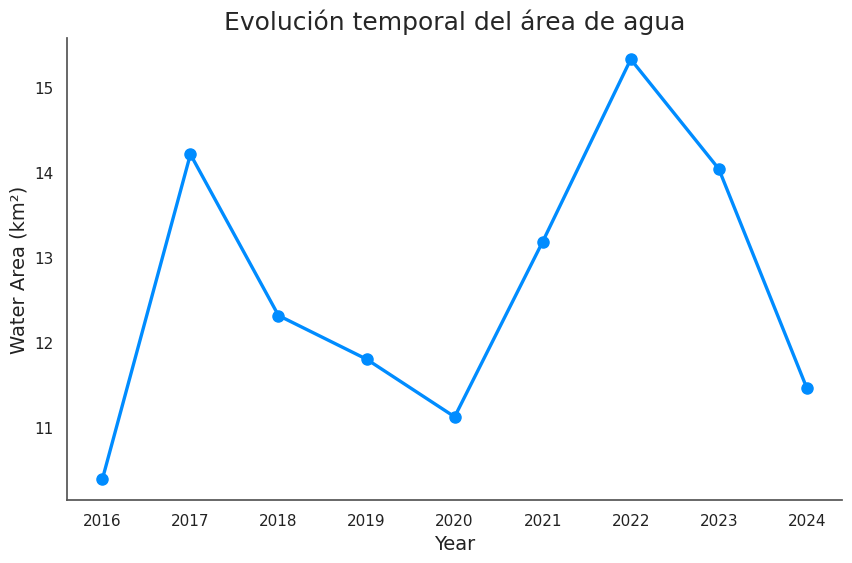

In [ ]:
plt.figure()
plt.plot(df['year'], df['water_area_km2'], marker='o')
plt.xlabel("Year")
plt.ylabel("Water Area (km²)")
plt.title("Evolución temporal del área de agua")
plt.grid()
plt.show()

In [ ]:
df.loc[df['water_area_change_rate'].abs() > 15]

,year,water_area_km2,mean_ndwi,std_ndwi,water_area_change_rate
1,2017,14.208328,-0.437642,0.231285,36.817906
5,2021,13.180181,-0.427453,0.203367,18.535570
6,2022,15.326183,-0.273882,0.140364,16.282034
8,2024,11.454973,-0.263547,0.124186,-18.384447


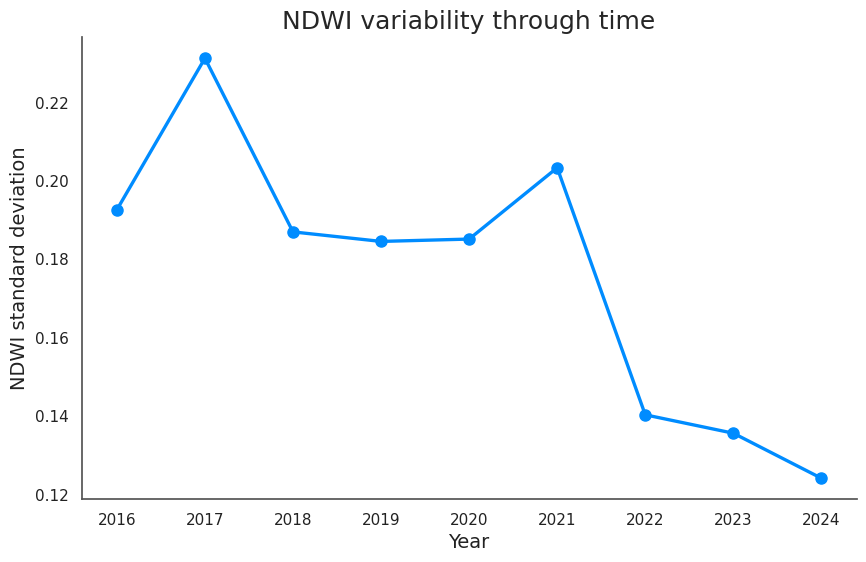

In [ ]:
plt.figure()
plt.plot(df['year'], df['std_ndwi'], marker='o')
plt.xlabel("Year")
plt.ylabel("NDWI standard deviation")
plt.title("NDWI variability through time")
plt.grid()
plt.show()

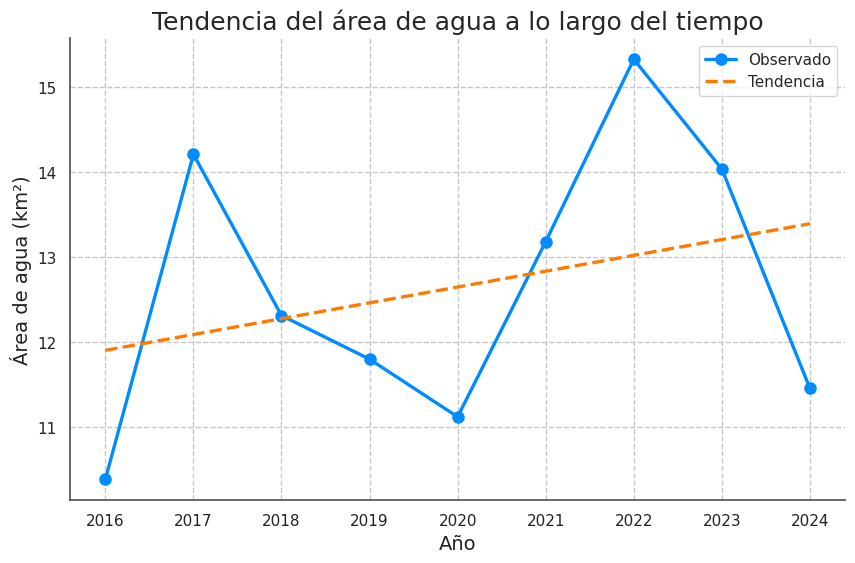

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df['year'].values.reshape(-1,1)
y = df['water_area_km2'].values

model = LinearRegression()
model.fit(X,y)

trend = model.predict(X)

plt.figure()
plt.plot(df['year'], y, marker='o', label='Observado')
plt.plot(df['year'], trend, label='Tendencia', linestyle='--')
plt.xlabel
plt.legend()
plt.title("Tendencia del área de agua a lo largo del tiempo")
plt.xlabel("Año")
plt.ylabel("Área de agua (km²)")
plt.grid
plt.show()

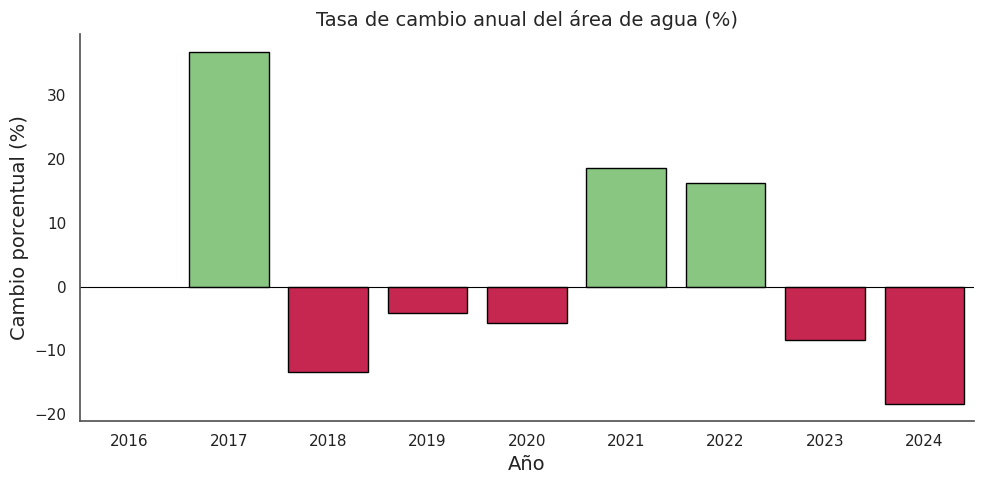

In [ ]:
plt.figure(figsize=(10,5))
# Colorear positivo verde, negativo rojo
colors = ['#80D177' if x > 0 else '#E00D43' if x < 0 else 'gray' for x in df['water_area_change_rate'].fillna(0)]
sns.barplot(data=df, x='year', y='water_area_change_rate', palette=colors, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Tasa de cambio anual del área de agua (%)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('change_rate.png', dpi=150)
plt.show()


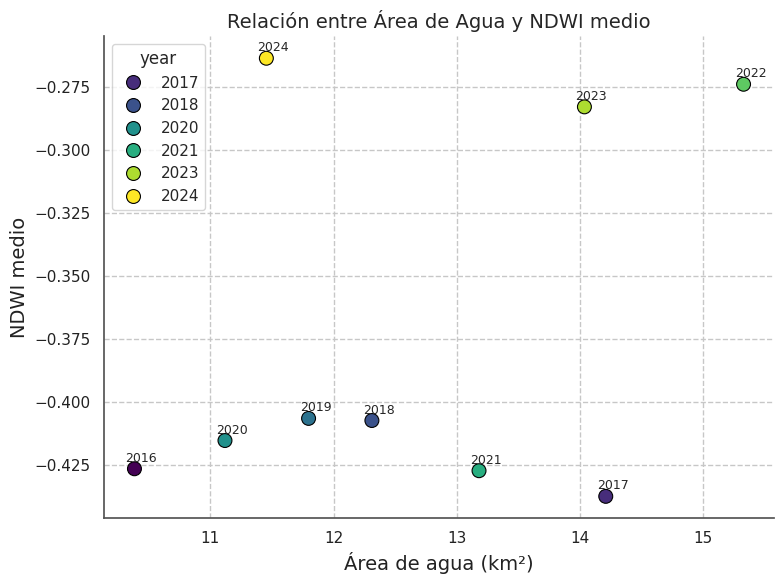

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='water_area_km2', y='mean_ndwi', hue='year', palette='viridis', s=100, edgecolor='black')
# Añadir etiquetas de año
for i, row in df.iterrows():
    plt.annotate(int(row['year']), (row['water_area_km2'], row['mean_ndwi']),
                 textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)
plt.title('Relación entre Área de Agua y NDWI medio', fontsize=14)
plt.xlabel('Área de agua (km²)')
plt.ylabel('NDWI medio')
plt.grid(True)
plt.tight_layout()
plt.savefig('area_vs_ndwi.png', dpi=150)
plt.show()


### Heatmap de la matriz de correlación

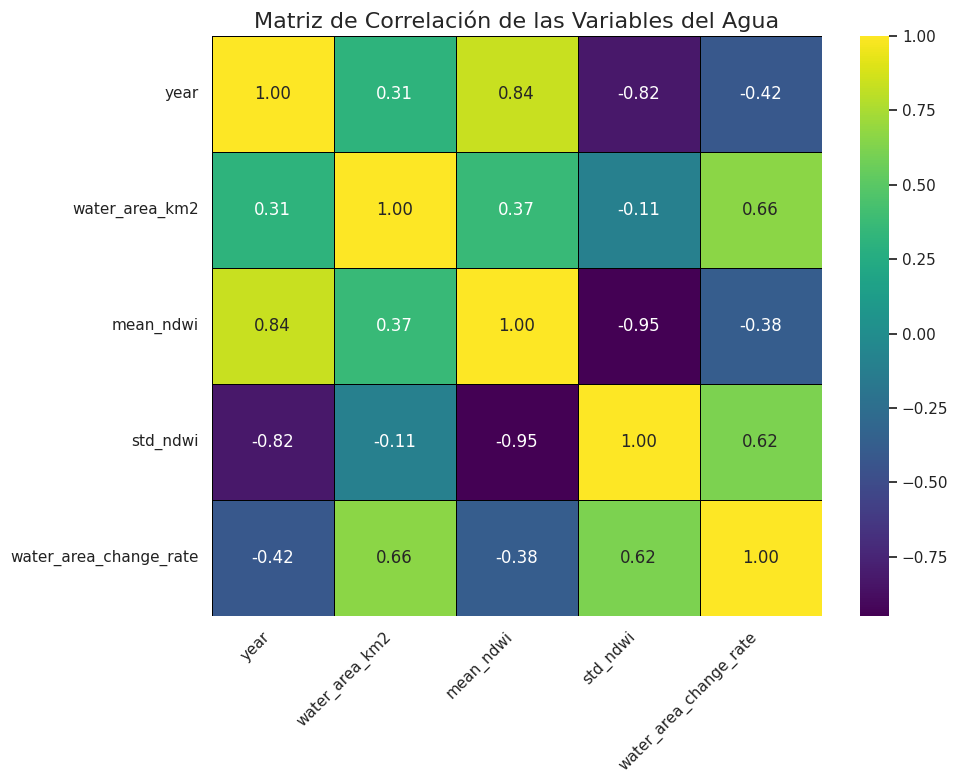

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='viridis',
            fmt=".2f",
            linewidths=.5,
            linecolor='black')
plt.title('Matriz de Correlación de las Variables del Agua', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

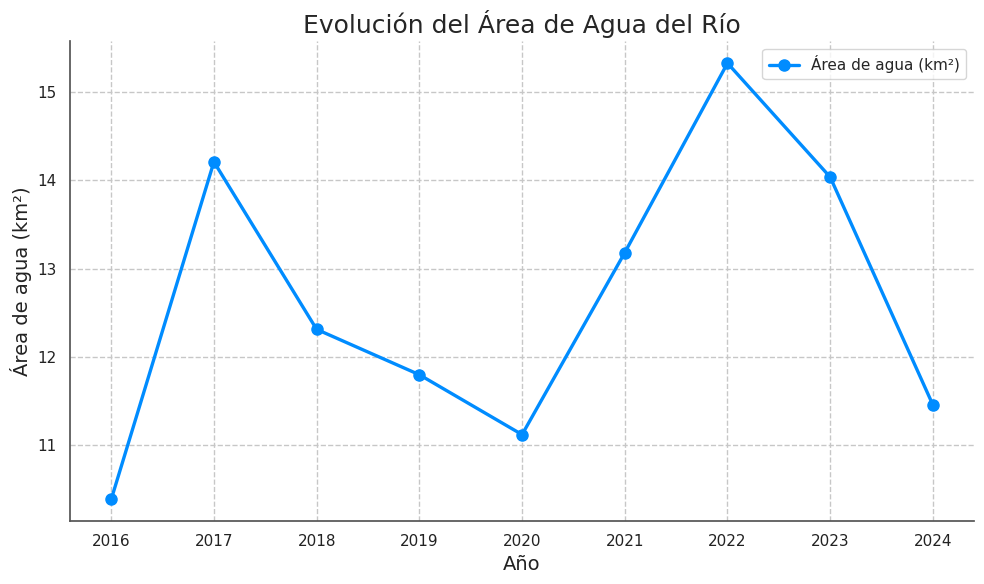

In [ ]:
plt.figure()
plt.plot(df['year'], df['water_area_km2'], marker='o', label="Área de agua (km²)")
plt.title("Evolución del Área de Agua del Río")
plt.xlabel("Año")
plt.ylabel("Área de agua (km²)")
plt.legend()
plt.tight_layout()
plt.show()

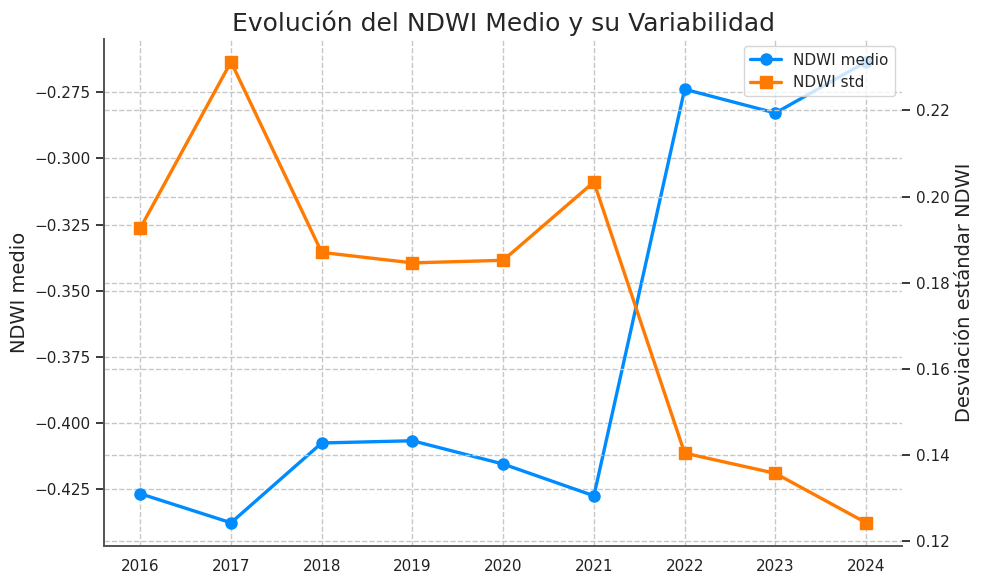

In [ ]:
fig, ax1 = plt.subplots()

# Línea NDWI medio
line1 = ax1.plot(df['year'], df['mean_ndwi'], marker='o',
                 color="#008CFF", label="NDWI medio")
ax1.set_ylabel("NDWI medio")

# Línea NDWI std en el segundo eje
ax2 = ax1.twinx()
line2 = ax2.plot(df['year'], df['std_ndwi'], marker='s',
                 color="#FF7A00", label="NDWI std")
ax2.set_ylabel("Desviación estándar NDWI")

# Combinar leyendas de ambos ejes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Evolución del NDWI Medio y su Variabilidad")
fig.tight_layout()
plt.show()

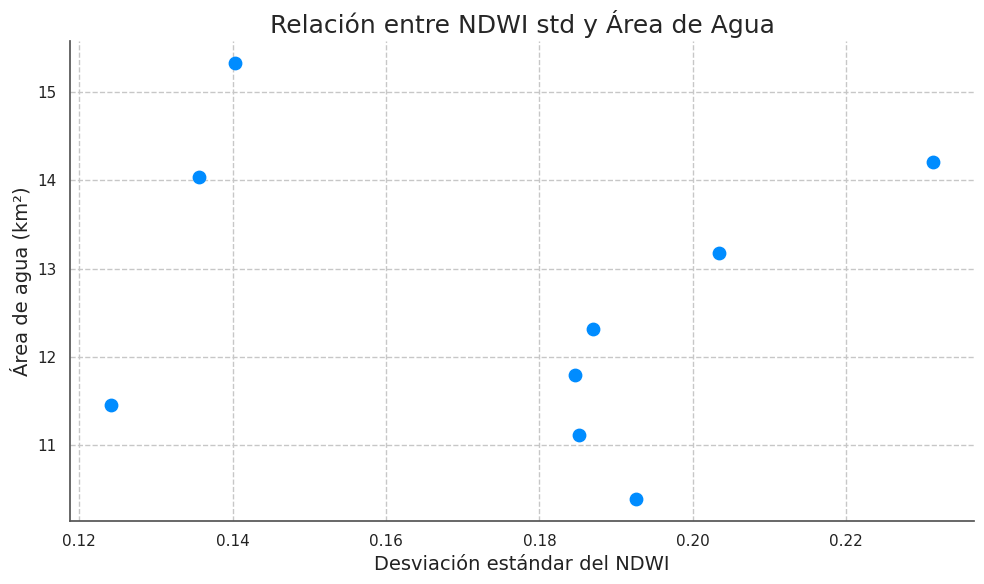

In [ ]:
plt.figure()
plt.scatter(df['std_ndwi'], df['water_area_km2'], s=80)
plt.title("Relación entre NDWI std y Área de Agua")
plt.xlabel("Desviación estándar del NDWI")
plt.ylabel("Área de agua (km²)")
plt.tight_layout()
plt.show()

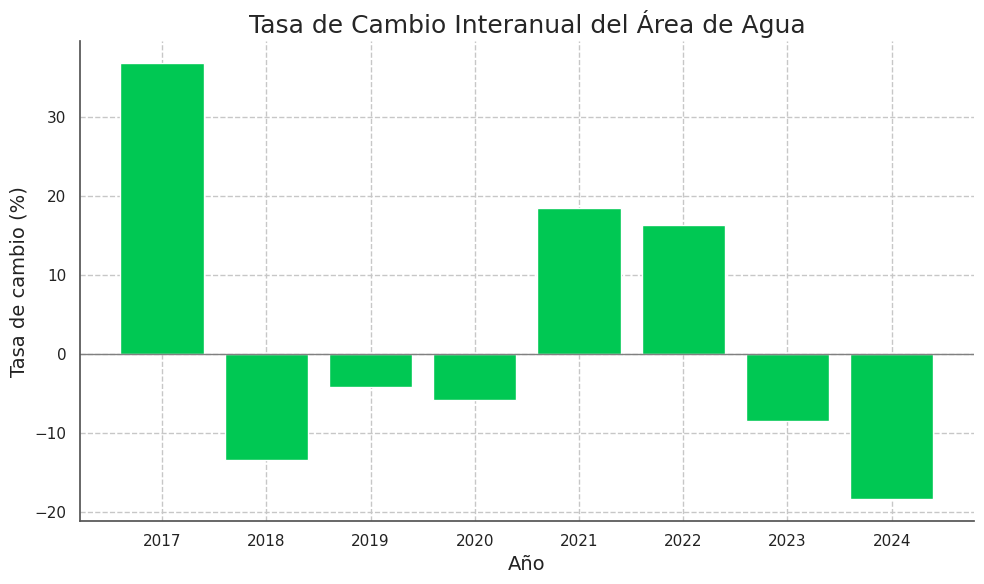

In [ ]:
plt.figure()
plt.bar(df['year'], df['water_area_change_rate'], color="#00C853")
plt.axhline(0, color="gray", linewidth=1)
plt.title("Tasa de Cambio Interanual del Área de Agua")
plt.xlabel("Año")
plt.ylabel("Tasa de cambio (%)")
plt.tight_layout()
plt.show()
